1️⃣ Handling missing values
2️⃣ Handling outlier
3️⃣ Encoding data kategorikal
4️⃣ Normalisasi / standardisasi
5️⃣ Split data train-test
6️⃣ Latih model KNN
7️⃣ Evaluasi
8️⃣ (Opsional) Tuning nilai K
9️⃣ Prediksi data baru

---

In [16]:
import pandas as pd

url = "/content/balita_fix.csv"
df = pd.read_csv(url)
df

,Umur,Jenis Kelamin,Tinggi Badan,Status Gizi
0,0,laki-laki,92,stunted
1,0,laki-laki,56,tinggi
2,0,laki-laki,92,normal
3,34,laki-laki,92,normal
4,0,laki-laki,92,severely stunted
...,...,...,...,...
120994,60,perempuan,92,normal
120995,60,perempuan,92,stunted
120996,60,perempuan,92,normal
120997,60,perempuan,112,normal


# Persiapan Data (Data Preparation)


*   Handling Missing Values → isi data kosong (imputasi) atau hapus baris dengan nilai kosong.
*   Handling Outlier → hilangkan atau ubah nilai ekstrem
*   Encoding Data Kategorikal → ubah data kategori menjadi numerik (misalnya dengan LabelEncoder atau OneHotEncoder). KNN hanya bisa menggunakan data numerik, jadi data yg kategori diubah menjadi numerik
*   Normalisasi/Standardisasi → skala semua fitur agar memiliki rentang nilai yang sama (karena KNN sensitif terhadap jarak).



---





*Kenapa harus di normalisasi*

| Usia (tahun) | Pendapatan (juta) |
| ------------ | ----------------- |
| 20           | 3                 |
| 30           | 6                 |
| 40           | 9                 |

Lihat skalanya:

Usia: 20–40 → beda cuma 20

Pendapatan: 3–9 juta → beda 6
Kalau satuan pendapatan diubah jadi rupiah (3.000.000–9.000.000), perbedaan jadi jutaan, dan KNN akan menganggap pendapatan lebih penting hanya karena angkanya besar 😅

In [17]:
#Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Jenis Kelamin'] = le.fit_transform(df['Jenis Kelamin'])
df['Status Gizi'] = le.fit_transform(df['Status Gizi'])
df.head()

,Umur,Jenis Kelamin,Tinggi Badan,Status Gizi
0,0,0,92,2
1,0,0,56,3
2,0,0,92,0
3,34,0,92,0
4,0,0,92,1


# *PUTUSKAN MANA YANG AKAN DI PREDIKSI*


*   Features (X) adalah Data masukan (input) yang digunakan model untuk memprediksi sesuatu.(umur, tinggi badan, jenis kelamin)
*   Target (Y) adalah Data keluaran (output) yang ingin diprediksi oleh model (Status gizi)

In [18]:
#PISAHKAN X dan Y
x = df.drop(columns=['Status Gizi'])
y = df['Status Gizi']

In [19]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Define X with the features to be scaled
X = df[['Umur', 'Jenis Kelamin' , 'Tinggi Badan']] # Assuming these are your features

scaler = StandardScaler()  # or MinMaxScaler()
X_scaled = scaler.fit_transform(X)

display(X_scaled)

array([[-1.87330258, -1.15374078,  0.15802121],
       [-1.87330258, -1.15374078, -2.24119353],
       [-1.87330258, -1.15374078,  0.15802121],
       ...,
       [ 1.78989404,  0.86674582,  0.15802121],
       [ 1.78989404,  0.86674582,  1.49091829],
       [ 1.78989404,  0.86674582,  1.29098373]])

*# SPLIT DATA TRAIN DAN TEST*

Kamu belajar matematika dengan latihan soal (training).
Lalu kamu ikut ujian akhir (testing).
Kalau nilai ujianmu bagus, berarti kamu beneran paham konsepnya, bukan cuma hafal soal latihan.

📌 Training data = soal latihan
📌 Testing data = soal ujian

| Jenis Data        | Tujuan                                           | Perbandingan Umum      |
| ----------------- | ------------------------------------------------ | ---------------------- |
| *Training data* | Untuk *melatih model* agar mengenal pola       | 70–80% dari total data |
| *Testing data*  | Untuk *menguji kemampuan model* pada data baru | 20–30% dari total data |



---


*# Terus, Kenapa HARUS DIPISAH?*

Kalau kamu melatih dan menguji model dengan data yang sama,
itu seperti kamu memberi tahu jawaban ujian ke model sebelum ujian 😅

In [20]:
from sklearn.model_selection import train_test_split  # Mengimpor fungsi train_test_split

# Membagi data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,      # Fitur (variabel independen) yang akan dibagi
    y,             # Variabel target (kolom yang ingin diprediksi)
    test_size=0.2, # Persentase data yang digunakan untuk pengujian (20%)
    random_state=42 # Agar hasil pembagian data selalu sama setiap kali kode dijalankan
)

PELAJARI ALGORITAM KNN
Algoritma KNN memprediksi sesuatu berdasarkan data yang paling mirip. Jadi kalau ada data baru, KNN akan mencari beberapa tetangga terdekat (K) dari data yang sudah diketahui hasilnya, lalu mengambil mayoritas dari mereka sebagai hasil prediksi.

#Prediksi dan evaluasi
from sklearn.metrics import accuracy_score, classification_report # Import classification_report

y_pred = knn.predict(X_test)

print("Akurasi:", accuracy_score(y_test, y_pred))
print("\nLaporan klasifikasi:\n", classification_report(y_test, y_pred))

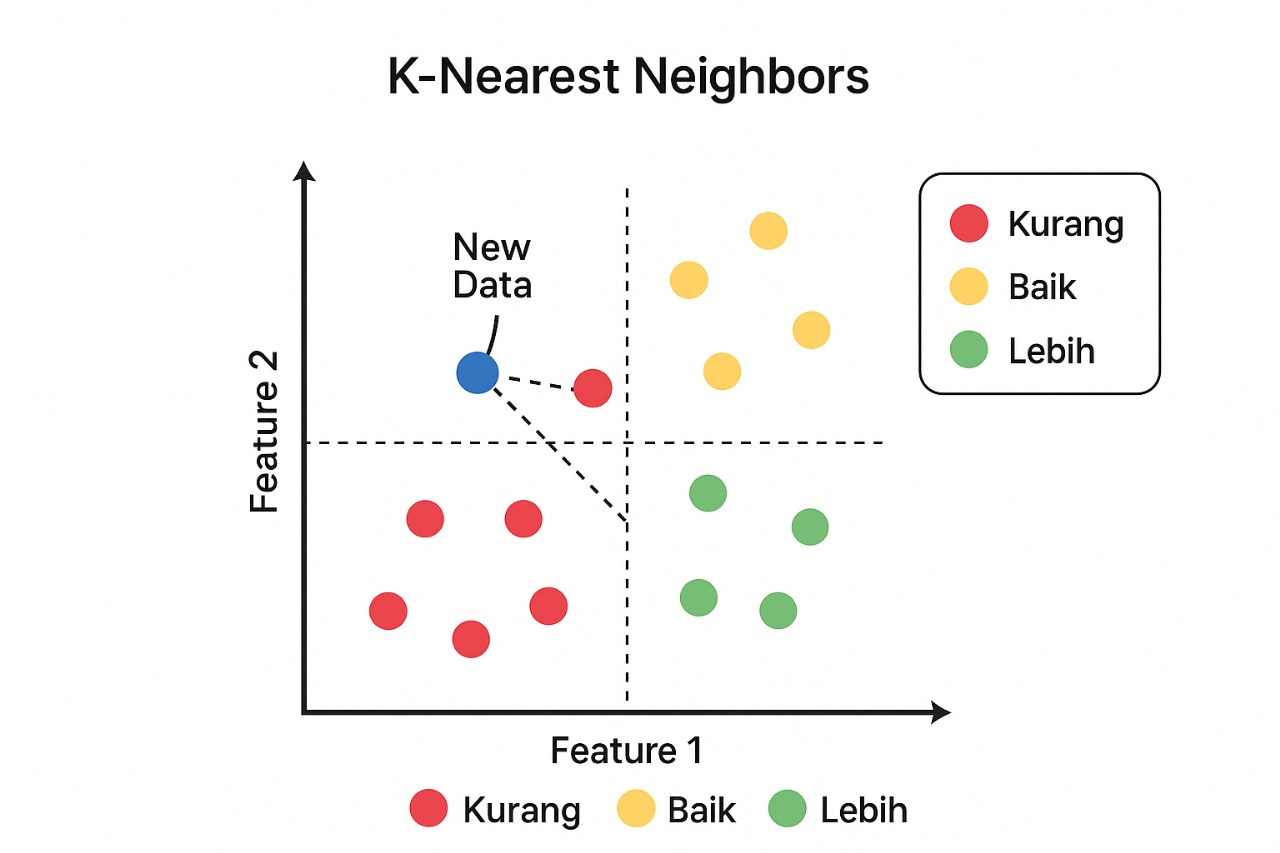

In [21]:
from sklearn.neighbors import KNeighborsClassifier #Import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=20)
knn.fit(X_train, y_train)


KNeighborsClassifier(n_neighbors=20)

In [22]:
#Prediksi dan evaluasi
from sklearn.metrics import accuracy_score, classification_report # Import classification_report

y_pred = knn.predict(X_test)

print("Akurasi:", accuracy_score(y_test, y_pred))
print("\nLaporan klasifikasi:\n", classification_report(y_test, y_pred))

Akurasi: 0.8227272727272728

Laporan klasifikasi:
               precision    recall  f1-score   support

           0       0.83      0.92      0.87     14786
           1       0.80      0.68      0.73      3598
           2       0.79      0.61      0.69      2429
           3       0.85      0.70      0.77      3387

    accuracy                           0.82     24200
   macro avg       0.82      0.73      0.76     24200
weighted avg       0.82      0.82      0.82     24200



In [23]:
# Misal data_baru SUDAH dinormalisasi sebelumnya
# contoh: umur= -0.25, jenis_kelamin= 1 (Laki-laki), tinggi_badan= -0.10
data_baru = pd.DataFrame({
    'Umur': [6],
    'Jenis Kelamin': [1],
    'Tinggi Badan': [30]
})

# Scale the new data using the same scaler
data_baru_scaled = scaler.transform(data_baru)

# langsung prediksi tanpa transform lagi
prediksi = knn.predict(data_baru_scaled)
hasil = le.inverse_transform(prediksi)

print("Status gizi diprediksi:", hasil[0])

Status gizi diprediksi: severely stunted


# *CEK ERROR RATE DAN OVERFITTING*

Error rate menunjukkan seberapa sering model salah memprediksi.

*Semakin kecil error rate, semakin baik modelmu.*
	​


---


Overfitting artinya model terlalu hafal data latih, tapi buruk pada data baru.

🧠 Tandanya:

Akurasi di data latih (train) tinggi.

Akurasi di data uji (test) rendah.

*Jika train_acc jauh lebih tinggi dari test_acc → Overfit*

*Jika keduanya mirip → Model baik / seimbang*

In [24]:
#CEK ERROR RATE
#Semakin kecil error rate, semakin baik modelmu.
from sklearn.metrics import accuracy_score

y_pred = knn.predict(X_test)

# Hitung error rate
error_rate = 1 - accuracy_score(y_test, y_pred)
print("Error rate:", error_rate)

Error rate: 0.17727272727272725


In [25]:
train_acc = knn.score(X_train, y_train)
test_acc = knn.score(X_test, y_test)

print("Akurasi data train:", train_acc)
print("Akurasi data test:", test_acc)

Akurasi data train: 0.824998192130084
Akurasi data test: 0.8227272727272728


# *CEK nilai K terbaik untuk model KNN data kita*
 grafik error rate terhadap nilai K agar kamu bisa melihat K terbaik untuk model KNN-mu 👇

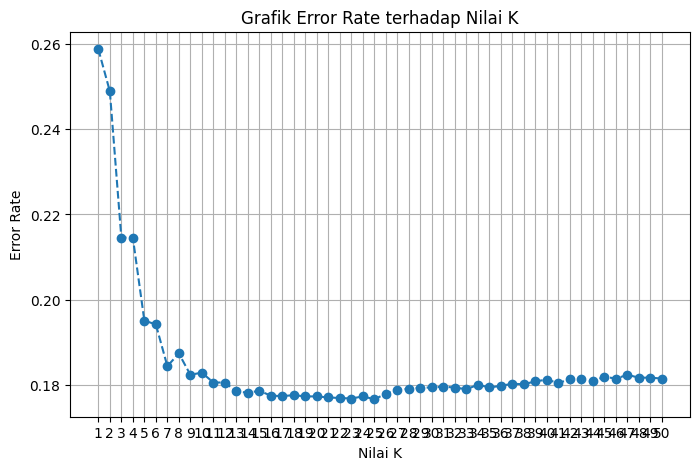

In [26]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

error_rates = []   # untuk simpan error rate tiap K
k_values = range(1, 51)  # coba K dari 1 sampai 20

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    error = 1 - accuracy_score(y_test, y_pred)
    error_rates.append(error)

# buat grafik
plt.figure(figsize=(8,5))
plt.plot(k_values, error_rates, marker='o', linestyle='--')
plt.title('Grafik Error Rate terhadap Nilai K')
plt.xlabel('Nilai K')
plt.ylabel('Error Rate')
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [27]:
import joblib


joblib.dump(knn, "model_knn_stunting.pkl")

joblib.dump(scaler, "scaler.pkl" )

['scaler.pkl']